# Hybrid BiTCN-BiGRU-Cross Attention + Semiogram Features
## Analisis Pola Langkah CVA dari Sinyal Accelerometer & Gyroscope IMU

**Judul Penelitian:**
*Analisis Pola Langkah Penderita CVA Menggunakan Sinyal Accelerometer dan Gyroscope dengan Hybrid BiTCN-BiGRU-Cross Attention dan Semiogram Features*

**Referensi Dataset:** Voisard et al. (2025). Scientific Data. https://doi.org/10.1038/s41597-025-05959-w

**Referensi Semiogram:** Voisard et al. (2025). Image Processing On Line. https://doi.org/10.5201/ipol.2025.535

---

### Arsitektur Pipeline

```
Raw IMU Time-Series (Acc+Gyro, 100 Hz)
    |
    +---> [ Acc stream: BiTCN -> BiGRU ]
    |              \
    |               Cross Attention ----> Temporal Embedding
    |              /
    +---> [ Gyro stream: BiTCN -> BiGRU ]
    |
    +---> Semiogram Features (deterministik, 17 param)
              |
              MLP Branch -----------------> Clinical Embedding
    |
    Fusion (Concat) -> FC -> Classifier Head -> Prob CVA
```

### Mengapa Desain Ini?

1. **Time-series sebagai input utama**: Sinyal IMU mentah mengandung pola temporal lokal dan global yang tidak dapat diringkas oleh fitur semiogram.
2. **Semiogram sebagai clinical prior**: 17 parameter gait (Voisard 2025) memberi interpretabilitas klinis dan pengetahuan domain yang sudah tervalidasi.
3. **BiTCN untuk pola lokal**: Temporal Convolutional Network dengan dilasi menangkap pola langkah lokal (heel-strike, swing) tanpa vanishing gradient.
4. **BiGRU untuk dependensi antar langkah**: Bidirectional GRU menangkap pola ritme dan simetri jangka panjang dalam satu trial.
5. **Cross Attention (Acc x Gyro)**: Akselerasi dan kecepatan sudut bersifat komplementer; attention memungkinkan model belajar interaksi non-linear di antara keduanya.
6. **Fusion hybrid**: Gabungan learned temporal features + handcrafted clinical features lebih kuat dari salah satunya saja.
7. **GroupKFold by subject**: Mencegah data leakage karena satu subjek bisa memiliki 2-16 trial.
8. **Dataset kecil (488 trial)**: Mitigasi dengan dropout, early stopping, class weighting, dan model kecil.


---
## TAHAP 1 -- LOAD DATASET (TIDAK DIUBAH)

### CELL 1.1 -- Import Dasar

In [16]:
import os
import json
import pandas as pd
import numpy as np
import pickle
from collections import defaultdict

In [17]:
import os
import zipfile

# Set paths untuk local dataset
base_path = os.path.abspath('.')
cva_path = os.path.join(base_path, 'CVA')
hs_path = os.path.join(base_path, 'HS')

print(f"Base path: {base_path}")
print(f"CVA path: {cva_path}")
print(f"HS path: {hs_path}")
print(f"CVA folder exists: {os.path.exists(cva_path)}")
print(f"HS folder exists: {os.path.exists(hs_path)}")

Base path: c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress
CVA path: c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA
HS path: c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\HS
CVA folder exists: True
HS folder exists: True


In [18]:
# Folder lokal sudah tersedia, tidak perlu extract
# Dataset sudah ada di folder CVA dan HS

# Verifikasi struktur folder
print("=== CVA Folders ===")
if os.path.exists(cva_path):
    cva_folders = sorted([d for d in os.listdir(cva_path) if os.path.isdir(os.path.join(cva_path, d))])
    print(f"Total CVA folders: {len(cva_folders)}")
    print(f"First few: {cva_folders[:5]}")
else:
    print("CVA folder tidak ditemukan!")

print("\n=== HS Folders ===")
if os.path.exists(hs_path):
    hs_folders = sorted([d for d in os.listdir(hs_path) if os.path.isdir(os.path.join(hs_path, d))])
    print(f"Total HS folders: {len(hs_folders)}")
    print(f"First few: {hs_folders[:5]}")
else:
    print("HS folder tidak ditemukan!")

=== CVA Folders ===
Total CVA folders: 49
First few: ['CVA_1', 'CVA_10', 'CVA_11', 'CVA_12', 'CVA_13']

=== HS Folders ===
Total HS folders: 73
First few: ['HS_1', 'HS_10', 'HS_11', 'HS_12', 'HS_13']


In [19]:
import os
import json

# Cari file meta di folder CVA dan HS
meta_files = []

# Cari di CVA
for root, dirs, files in os.walk(cva_path):
    for f in files:
        if f.endswith("_meta.json"):
            meta_files.append(os.path.join(root, f))

# Cari di HS
for root, dirs, files in os.walk(hs_path):
    for f in files:
        if f.endswith("_meta.json"):
            meta_files.append(os.path.join(root, f))

print(f"Total meta files ditemukan: {len(meta_files)}")
for p in meta_files[:5]:
    print(p)

Total meta files ditemukan: 488
c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA\CVA_1\CVA_1_1\CVA_1_1_meta.json
c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA\CVA_1\CVA_1_2\CVA_1_2_meta.json
c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA\CVA_10\CVA_10_1\CVA_10_1_meta.json
c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA\CVA_10\CVA_10_2\CVA_10_2_meta.json
c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA\CVA_11\CVA_11_1\CVA_11_1_meta.json


In [20]:
# Tampilkan struktur direktori lokal
print("=== STRUKTUR FOLDER CVA ===")
for root, dirs, files in os.walk(cva_path):
    depth = root.replace(cva_path, '').count(os.sep)
    if depth > 2:  # Batasi kedalaman
        continue
    indent = '  ' * depth
    print(f"{indent}📁 {os.path.basename(root)}/")
    for f in files[:3]:
        print(f"{indent}   📄 {f}")
    if len(files) > 3:
        print(f"{indent}   ... (+{len(files)-3} files)")

print("\n=== STRUKTUR FOLDER HS ===")
for root, dirs, files in os.walk(hs_path):
    depth = root.replace(hs_path, '').count(os.sep)
    if depth > 2:  # Batasi kedalaman
        continue
    indent = '  ' * depth
    print(f"{indent}📁 {os.path.basename(root)}/")
    for f in files[:3]:
        print(f"{indent}   📄 {f}")
    if len(files) > 3:
        print(f"{indent}   ... (+{len(files)-3} files)")

=== STRUKTUR FOLDER CVA ===
📁 CVA/
  📁 CVA_1/
    📁 CVA_1_1/
       📄 CVA_1_1_meta.json
       📄 CVA_1_1_plot.png
       📄 CVA_1_1_processed_data.txt
       ... (+4 files)
    📁 CVA_1_2/
       📄 CVA_1_2_meta.json
       📄 CVA_1_2_plot.png
       📄 CVA_1_2_processed_data.txt
       ... (+4 files)
  📁 CVA_10/
    📁 CVA_10_1/
       📄 CVA_10_1_meta.json
       📄 CVA_10_1_plot.png
       📄 CVA_10_1_processed_data.txt
       ... (+4 files)
    📁 CVA_10_2/
       📄 CVA_10_2_meta.json
       📄 CVA_10_2_plot.png
       📄 CVA_10_2_processed_data.txt
       ... (+4 files)
  📁 CVA_11/
    📁 CVA_11_1/
       📄 CVA_11_1_meta.json
       📄 CVA_11_1_plot.png
       📄 CVA_11_1_processed_data.txt
       ... (+4 files)
    📁 CVA_11_2/
       📄 CVA_11_2_meta.json
       📄 CVA_11_2_plot.png
       📄 CVA_11_2_processed_data.txt
       ... (+4 files)
  📁 CVA_12/
    📁 CVA_12_1/
       📄 CVA_12_1_meta.json
       📄 CVA_12_1_plot.png
       📄 CVA_12_1_processed_data.txt
       ... (+4 files)
    📁 CVA_12_2/


---
## TAHAP 2 -- INSTALL DEPENDENCIES & IMPORT

In [21]:
# !pip install torch torchvision scikit-learn xgboost imbalanced-learn tqdm -q

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"✅ Device: {DEVICE}")
print(f"✅ PyTorch: {torch.__version__}")

✅ Device: cpu
✅ PyTorch: 2.11.0+cpu


---
## TAHAP 3 -- LOAD META FILES (CVA + HS)

In [22]:
def find_cohort_folder(base, prefix):
    for root, dirs, files in os.walk(base):
        for d in dirs:
            if d.upper() == prefix.upper():
                return os.path.join(root, d)
    return os.path.join(base, "DatasetGait", prefix)


def load_all_meta(base_path, cohort_prefix):
    records = []
    if not os.path.exists(base_path):
        print(f"  WARNING path not found: {base_path}")
        return records
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if not f.endswith("_meta.json"):
                continue
            path = os.path.join(root, f)
            try:
                with open(path) as fp:
                    meta = json.load(fp)
            except Exception:
                continue
            name  = f.replace("_meta.json", "")
            parts = name.split("_")
            if len(parts) < 3:
                continue
            subject_id = "_".join(parts[:-1])
            try:
                trial_id = int(parts[-1])
            except ValueError:
                continue
            records.append({
                "Subject_ID": subject_id,
                "Trial_ID":   trial_id,
                "meta":       meta,
                "trial_dir":  root,
                "cohort":     cohort_prefix,
            })
    return records


# Gunakan paths lokal yang sudah didefinisikan di cell sebelumnya
# cva_path dan hs_path sudah siap dari setup lokal
print(f"CVA path: {cva_path}")
print(f"HS  path: {hs_path}")

cva_records = load_all_meta(cva_path, "CVA")
hs_records  = load_all_meta(hs_path,  "HS")
all_records = cva_records + hs_records

print(f"\n✅ CVA trials: {len(cva_records)}")
print(f"✅ HS  trials: {len(hs_records)}")
print(f"✅ Total     : {len(all_records)}")

CVA path: c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\CVA
HS  path: c:\Users\fizel\OneDrive\Documents\Proyek Penelitian_Progress\HS

✅ CVA trials: 128
✅ HS  trials: 360
✅ Total     : 488


---
## TAHAP 4 -- BUILD TIME-SERIES DATASET

**Input:** File `_processed_data.txt` setiap trial
**Channels yang digunakan (dari sensor Lower Back / LB):**
- Acc: `LB_FreeAcc_X` (AP), `LB_FreeAcc_Y` (ML), `LB_FreeAcc_Z` (CC)
- Gyr: `LB_Gyr_X`, `LB_Gyr_Y`, `LB_Gyr_Z`

**Mengapa LB sensor?**
Sensor lower back (L4/L5) adalah sensor utama untuk analisis gait klinis sesuai Voisard 2025.
Semiogram juga dihitung dari sensor ini.

**Tensor shape:** `(N_trials, T, C)` dengan C=6, T=T_MAX (fixed length via padding/truncation)


In [23]:
FS     = 100       # sampling frequency Hz
T_MAX  = 400       # ~4 detik pada 100 Hz; cukup untuk 1 round-trip pendek
N_CHAN = 6         # LB: 3 acc + 3 gyr

# Kolom prioritas (LB sensor) -- FreeAcc jika ada, fallback ke Acc
ACC_COLS_PRIORITY = [
    ["LB_FreeAcc_X","LB_FreeAcc_Y","LB_FreeAcc_Z"],
    ["LB_Acc_X",    "LB_Acc_Y",    "LB_Acc_Z"],
]
GYR_COLS = ["LB_Gyr_X","LB_Gyr_Y","LB_Gyr_Z"]


def find_columns(df_cols, candidates_list):
    cols_lower = [c.lower() for c in df_cols]
    for cands in candidates_list:
        found = []
        for c in cands:
            matches = [df_cols[i] for i, x in enumerate(cols_lower) if c.lower() in x]
            if matches:
                found.append(matches[0])
        if len(found) == 3:
            return found
    return None


def load_timeseries(trial_dir, t_max=T_MAX):
    # Load dan return array (T, 6) dari processed data file.
    proc_file = None
    for fname in os.listdir(trial_dir):
        if "processed" in fname.lower() and fname.endswith(".txt"):
            proc_file = os.path.join(trial_dir, fname)
            break
    if proc_file is None:
        return None

    # Baca dengan beberapa separator
    df = None
    for sep in ["\t", " ", ","]:
        try:
            tmp = pd.read_csv(proc_file, sep=sep, engine="python")
            if tmp.shape[1] >= 6:
                df = tmp
                break
        except Exception:
            continue
    if df is None or df.shape[1] < 6:
        return None

    df_cols = list(df.columns)

    # Acc
    acc_cols = find_columns(df_cols, ACC_COLS_PRIORITY)
    if acc_cols is None:
        return None

    # Gyr
    gyr_candidates = [[c] for c in GYR_COLS]
    gyr_found = []
    cols_lower = [c.lower() for c in df_cols]
    for gc in GYR_COLS:
        matches = [df_cols[i] for i, x in enumerate(cols_lower) if gc.lower() in x]
        if matches:
            gyr_found.append(matches[0])
    if len(gyr_found) < 3:
        return None

    try:
        acc = df[acc_cols].values.astype(float)
        gyr = df[gyr_found].values.astype(float)
    except Exception:
        return None

    sig = np.hstack([acc, gyr])  # (T_total, 6)

    # Handle NaN
    for ch in range(sig.shape[1]):
        nans = np.isnan(sig[:, ch])
        if nans.any() and (~nans).sum() > 0:
            sig[nans, ch] = np.interp(
                np.where(nans)[0], np.where(~nans)[0], sig[~nans, ch]
            )
    sig = np.nan_to_num(sig, nan=0.0)

    # Pad / truncate
    T = sig.shape[0]
    if T >= t_max:
        sig = sig[:t_max, :]
    else:
        pad = np.zeros((t_max - T, 6))
        sig = np.vstack([sig, pad])

    return sig.astype(np.float32)  # (T_MAX, 6)


print("✅ Fungsi load_timeseries siap.")
print(f"   T_MAX={T_MAX}, N_CHAN={N_CHAN}")

✅ Fungsi load_timeseries siap.
   T_MAX=400, N_CHAN=6


In [24]:
print("⏳ Loading time-series data...")

ts_data    = []  # list of (T_MAX, 6) arrays
ts_labels  = []  # 0=HS, 1=CVA
ts_subjects= []  # subject ID
ts_trial_ids = []
ts_fma_le  = []  # FMA-LE (NaN for HS)
ts_loaded  = []  # bool mask of successful loads

skipped = 0
for rec in tqdm(all_records, desc="TS Load"):
    sig = load_timeseries(rec["trial_dir"], T_MAX)
    if sig is None:
        skipped += 1
        ts_loaded.append(False)
        continue
    ts_loaded.append(True)

    label = 1 if rec["cohort"] == "CVA" else 0
    meta  = rec["meta"]
    fma   = meta.get("evaluationScoreValue", np.nan)
    if fma is not None:
        try: fma = float(fma)
        except: fma = np.nan
    else:
        fma = np.nan

    ts_data.append(sig)
    ts_labels.append(label)
    ts_subjects.append(rec["Subject_ID"])
    ts_trial_ids.append(rec["Trial_ID"])
    ts_fma_le.append(fma)

X_ts     = np.stack(ts_data, axis=0)      # (N, T, C)
y_ts     = np.array(ts_labels)            # (N,)
g_ts     = np.array(ts_subjects)          # (N,)
fma_arr  = np.array(ts_fma_le)            # (N,)

print(f"\n✅ X_ts shape   : {X_ts.shape}")
print(f"✅ Loaded trials: {len(ts_data)} / {len(all_records)} (skipped={skipped})")
print(f"✅ CVA (1): {(y_ts==1).sum()}, HS (0): {(y_ts==0).sum()}")
print(f"✅ Unique subjects: {len(np.unique(g_ts))}")

⏳ Loading time-series data...


TS Load: 100%|██████████| 488/488 [00:50<00:00,  9.60it/s]


✅ X_ts shape   : (488, 400, 6)
✅ Loaded trials: 488 / 488 (skipped=0)
✅ CVA (1): 128, HS (0): 360
✅ Unique subjects: 122


### CELL 4.1 -- Visualisasi Sample Sinyal

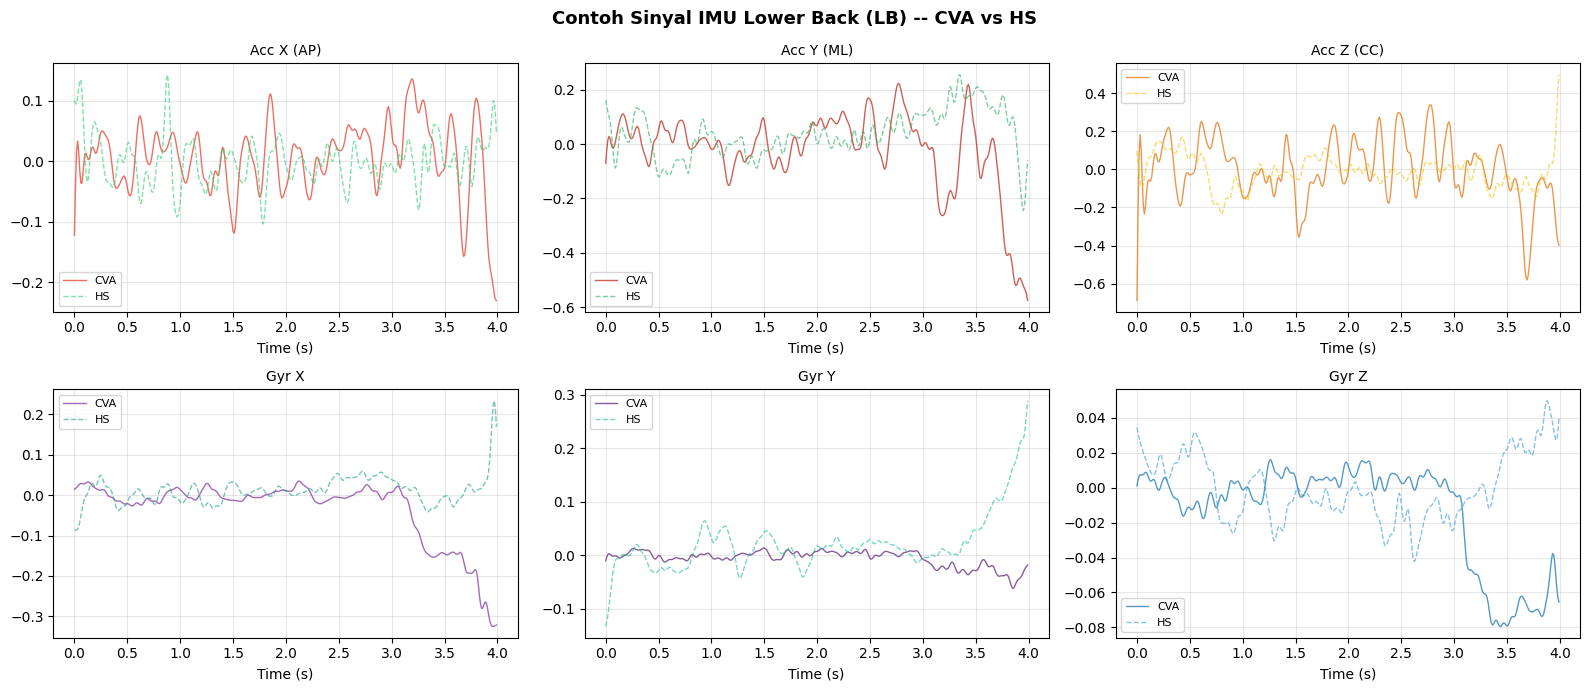

✅ Saved -> signal_samples.png (local)


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.suptitle("Contoh Sinyal IMU Lower Back (LB) -- CVA vs HS", fontsize=13, fontweight="bold")

channel_names = ["Acc X (AP)", "Acc Y (ML)", "Acc Z (CC)",
                 "Gyr X",      "Gyr Y",      "Gyr Z"]
colors_cva = ["#e74c3c","#c0392b","#e67e22","#8e44ad","#6c3483","#2980b9"]
colors_hs  = ["#2ecc71","#27ae60","#f1c40f","#16a085","#1abc9c","#3498db"]

# Pilih sample pertama CVA dan HS
idx_cva = np.where(y_ts == 1)[0][0]
idx_hs  = np.where(y_ts == 0)[0][0]
t_axis  = np.arange(T_MAX) / FS

for i, (ax, name) in enumerate(zip(axes.flat, channel_names)):
    ax.plot(t_axis, X_ts[idx_cva, :, i], color=colors_cva[i], alpha=0.8, linewidth=1, label="CVA")
    ax.plot(t_axis, X_ts[idx_hs,  :, i], color=colors_hs[i],  alpha=0.6, linewidth=1, label="HS", linestyle="--")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("signal_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved -> signal_samples.png (local)")

---
## TAHAP 5 -- SEMIOGRAM FEATURES (Clinical Prior)

Parameter semiogram dihitung dari metadata gait events + sinyal LB sesuai algoritma Voisard 2025.
17 parameter ini menjadi *handcrafted clinical embedding* yang dilengkapi model deep learning.

**Kelompok parameter:**
- Average speed: V
- Springiness: StrT, UtrT
- Smoothness: SPARC, LDLJ
- Steadiness: CVStrT, CVdstT, P1aCC, P2aCC
- Sturdiness: SteL
- Stability: RMSaML
- Symmetry: iHRaAP, iHRaML, iHRaCC, P1P2aCC, swTr
- Synchronization: dstT


In [26]:
from scipy.signal import welch, butter, filtfilt
from scipy.fft import rfft, rfftfreq

FS = 100

def remove_outliers(v, zlim=2.0):
    v = np.array(v, dtype=float)
    if len(v) < 3:
        return v
    mu = np.mean(v); sd = np.std(v)
    if sd < 1e-9:
        return v
    return v[np.abs((v - mu)/sd) <= zlim]

def compute_sparc_gyr(gyr_norm, fs=FS, padlevel=4, fc=10.0, amp_th=0.05):
    n = len(gyr_norm)
    if n < 20:
        return np.nan
    nfft = int(2 ** (np.ceil(np.log2(n)) + padlevel))
    Mf   = np.abs(rfft(gyr_norm, n=nfft))
    freq = rfftfreq(nfft, d=1.0/fs)
    mx   = Mf.max()
    if mx < 1e-9:
        return np.nan
    Mf_n = Mf / mx
    idx  = (freq <= fc) & (Mf_n >= amp_th)
    if idx.sum() < 2:
        return np.nan
    fn = (freq[idx] - freq[idx][0]) / (freq[idx][-1] - freq[idx][0] + 1e-9)
    mn = Mf_n[idx]
    return float(-np.sum(np.sqrt(np.diff(fn)**2 + np.diff(mn)**2)))

def compute_ldlj_acc(acc_mag, fs=FS):
    M = len(acc_mag)
    if M < 10:
        return np.nan
    mx = acc_mag.max()
    if mx < 1e-6:
        return np.nan
    s    = M / (fs * mx**2)
    jerk = np.diff(acc_mag) * fs
    val  = -np.log(abs(s * (1/fs) * np.sum(jerk**2)) + 1e-12)
    return float(val)

def autocorr_fft(x):
    n = len(x)
    xc = x - np.mean(x)
    f  = rfft(xc, n=2*n)
    ac = np.real(np.fft.irfft(f * np.conj(f)))[:n]
    denom = ac[0]
    if denom < 1e-9:
        return np.zeros(n)
    return ac / denom

def improved_hr(acc_axis, hs_times, fs=FS, axis_type="AP"):
    # Improved Harmonic Ratio sesuai Voisard 2025.
    if len(hs_times) < 4:
        return np.nan
    ihrs = []
    for k in range(1, len(hs_times)-1):
        h0, h1 = hs_times[k], hs_times[k+1]
        if h1 <= h0 or h1 > len(acc_axis):
            continue
        seg = acc_axis[h0:h1]
        if len(seg) < 10:
            continue
        Mf  = np.abs(rfft(seg))
        # fundamental: fs / nsample
        # even / odd harmonics for AP&CC / ML
        n_harm = min(10, len(Mf)//2)
        if n_harm < 2:
            continue
        if axis_type in ["AP","CC"]:
            even = sum(Mf[2*j]**2 for j in range(1, n_harm+1) if 2*j < len(Mf))
            odd  = sum(Mf[2*j-1]**2 for j in range(1, n_harm+1) if 2*j-1 < len(Mf))
        else:  # ML
            odd  = sum(Mf[2*j-1]**2 for j in range(1, n_harm+1) if 2*j-1 < len(Mf))
            even = sum(Mf[2*j]**2   for j in range(1, n_harm+1) if 2*j < len(Mf))
        total = even + odd
        if total < 1e-9:
            continue
        ihrs.append(100 * even / total if axis_type in ["AP","CC"] else 100 * odd / total)
    return float(np.mean(ihrs)) if ihrs else np.nan


def compute_semiogram(rec, loaded_sig=None):
    # Hitung 17 parameter semiogram sesuai Voisard 2025.
    meta      = rec["meta"]
    trial_dir = rec["trial_dir"]
    row = {"Subject_ID": rec["Subject_ID"],
           "Trial_ID":   rec["Trial_ID"],
           "cohort":     rec["cohort"]}

    # ── Gait events ─────────────────────────────────────────────
    ev_L = meta.get("leftGaitEvents",  [])
    ev_R = meta.get("rightGaitEvents", [])
    utb  = meta.get("uturnBoundaries", None)

    hs_L = sorted([int(e[1]) for e in ev_L if len(e)>=2])
    hs_R = sorted([int(e[1]) for e in ev_R if len(e)>=2])
    to_L = sorted([int(e[0]) for e in ev_L if len(e)>=2])
    to_R = sorted([int(e[0]) for e in ev_R if len(e)>=2])

    N_L, N_R = len(hs_L), len(hs_R)

    # U-turn time
    if utb and len(utb) >= 2:
        row["UtrT"] = float(utb[1] - utb[0]) / FS
        u_start, u_end = int(utb[0]), int(utb[1])
    else:
        row["UtrT"] = np.nan
        u_start, u_end = 0, 0

    # TUG
    tug = meta.get("TUG", np.nan)
    row["TUG"] = float(tug) if tug is not None else np.nan

    # ── Stride parameters ────────────────────────────────────────
    strides_L = remove_outliers(np.diff(hs_L)/FS) if N_L>1 else np.array([])
    strides_R = remove_outliers(np.diff(hs_R)/FS) if N_R>1 else np.array([])
    strides   = np.concatenate([strides_L, strides_R])
    strides   = strides[(strides>0.5)&(strides<3.0)] if len(strides)>0 else strides

    StrT  = float(np.mean(strides))  if len(strides)>0 else np.nan
    CVStrT= float(np.std(strides)/(np.mean(strides)+1e-9)*100) if len(strides)>1 else np.nan
    row["StrT"]   = StrT
    row["CVStrT"] = CVStrT

    # ── Double stance ─────────────────────────────────────────────
    dst_list = []
    for i in range(N_R-1):
        cycle_dur = (hs_R[i+1]-hs_R[i])
        if cycle_dur < 1: continue
        # Find left swing ending in this cycle
        js = [j for j,h in enumerate(hs_L) if hs_R[i] < h < hs_R[i+1]]
        if not js: continue
        j  = js[0]
        if j < len(to_L):
            d = ((hs_R[i+1]-to_L[j])+(to_R[i]-hs_R[i])) / cycle_dur if i<len(to_R) else np.nan
            if not np.isnan(d) and 0 < d < 1:
                dst_list.append(d)
    dst_arr  = remove_outliers(np.array(dst_list)) if dst_list else np.array([])
    row["dstT"]   = float(np.mean(dst_arr)*100) if len(dst_arr)>0 else np.nan
    row["CVdstT"] = float(np.std(dst_arr)/(np.mean(dst_arr)+1e-9)*100) if len(dst_arr)>1 else np.nan

    # ── Step length & velocity ────────────────────────────────────
    all_hs = sorted(hs_L + hs_R)
    if len(all_hs) >= 2:
        walk_dur = (max(all_hs)-min(all_hs))/FS
        if u_end > u_start:
            walk_dur -= (u_end-u_start)/FS
        walk_dur = max(walk_dur, 0.1)
        row["V"]    = float(10.0 / walk_dur)
        total_steps = N_L + N_R
        row["SteL"] = float(20.0 / total_steps) if total_steps>0 else np.nan
    else:
        row["V"]    = np.nan
        row["SteL"] = np.nan

    # ── Swing time ratio ─────────────────────────────────────────
    sw_L = remove_outliers(np.array([(hs_L[i]-to_L[i])/FS
                                      for i in range(min(N_L,len(to_L)))
                                      if hs_L[i]>to_L[i]]))
    sw_R = remove_outliers(np.array([(hs_R[i]-to_R[i])/FS
                                      for i in range(min(N_R,len(to_R)))
                                      if hs_R[i]>to_R[i]]))
    swL = float(np.mean(sw_L)) if len(sw_L)>0 else np.nan
    swR = float(np.mean(sw_R)) if len(sw_R)>0 else np.nan
    if not np.isnan(swL) and not np.isnan(swR) and max(swL,swR)>0:
        row["swTr"] = float(min(swL,swR)/max(swL,swR))
    else:
        row["swTr"] = np.nan

    # ── Signal-based features from processed data ─────────────────
    for k in ["RMSaML","SPARCrot","LDLJ","P1aCC","P2aCC","P1P2aCC",
              "iHRaAP","iHRaML","iHRaCC"]:
        row[k] = np.nan

    if loaded_sig is not None:
        acc_x = loaded_sig[:,0].astype(float)  # AP (craniocaudal for LB)
        acc_y = loaded_sig[:,1].astype(float)  # ML
        acc_z = loaded_sig[:,2].astype(float)  # CC
        gyr_x = loaded_sig[:,3].astype(float)
        gyr_y = loaded_sig[:,4].astype(float)
        gyr_z = loaded_sig[:,5].astype(float)

        # Walking phase only (exclude waiting + u-turn)
        if len(all_hs)>=2:
            t0 = max(0, min(all_hs)-50)
            t1 = min(loaded_sig.shape[0]-1, max(all_hs)+50)
        else:
            t0, t1 = 0, loaded_sig.shape[0]-1

        # Separate go/back if u-turn available
        if u_start > t0+20 and u_end < t1-20:
            go_slice   = slice(t0, u_start)
            back_slice = slice(u_end, t1)
        else:
            go_slice = back_slice = slice(t0, t1)

        # RMSaML (best of go/back)
        rms_go   = float(np.sqrt(np.mean(acc_y[go_slice]**2)))
        rms_back = float(np.sqrt(np.mean(acc_y[back_slice]**2)))
        row["RMSaML"] = float(min(rms_go, rms_back))

        # SPARC from gyr norm
        gyr_norm = np.sqrt(gyr_x[t0:t1]**2 + gyr_y[t0:t1]**2 + gyr_z[t0:t1]**2)
        row["SPARCrot"] = compute_sparc_gyr(gyr_norm)

        # LDLJ from acc mag
        acc_mag_go   = np.sqrt(acc_x[go_slice]**2 + acc_y[go_slice]**2 + acc_z[go_slice]**2)
        acc_mag_back = np.sqrt(acc_x[back_slice]**2 + acc_y[back_slice]**2 + acc_z[back_slice]**2)
        ldlj_go   = compute_ldlj_acc(acc_mag_go)
        ldlj_back = compute_ldlj_acc(acc_mag_back)
        if not np.isnan(ldlj_go) and not np.isnan(ldlj_back):
            row["LDLJ"] = float(0.5*(ldlj_go+ldlj_back))
        elif not np.isnan(ldlj_go):
            row["LDLJ"] = ldlj_go

        # Autocorrelation P1/P2 (craniocaudal = acc_x for LB)
        if not np.isnan(StrT) and StrT > 0:
            ac = autocorr_fft(acc_x[t0:t1])
            n_ac = len(ac)
            p1_lo = int(StrT/3*FS)
            p1_hi = int(2*StrT/3*FS)
            p2_lo = int(5*StrT/6*FS)
            p2_hi = int(7*StrT/6*FS)
            if p1_hi < n_ac:
                row["P1aCC"] = float(ac[p1_lo:p1_hi].max())
            if p2_hi < n_ac:
                row["P2aCC"] = float(ac[p2_lo:p2_hi].max())
            if not np.isnan(row["P1aCC"]) and not np.isnan(row["P2aCC"]) and row["P2aCC"]>1e-6:
                p1p2 = abs(1 - row["P1aCC"]/row["P2aCC"])
                row["P1P2aCC"] = float(1 - min(p1p2, 1))

        # Improved Harmonic Ratios
        if len(hs_L)+len(hs_R) >= 4:
            all_hs_sorted = sorted(hs_L + hs_R)
            hs_arr = [h for h in all_hs_sorted if t0 <= h <= t1]
            if len(hs_arr) >= 4:
                row["iHRaAP"] = improved_hr(acc_x, hs_arr, FS, "AP")
                row["iHRaML"] = improved_hr(acc_y, hs_arr, FS, "ML")
                row["iHRaCC"] = improved_hr(acc_z, hs_arr, FS, "CC")

    return row

print("✅ Fungsi compute_semiogram siap (17 parameter sesuai Voisard 2025).")

✅ Fungsi compute_semiogram siap (17 parameter sesuai Voisard 2025).


In [28]:
print("⏳ Menghitung semiogram untuk semua trial...")

semi_rows  = []
loaded_idx = 0  # index ke X_ts (hanya trial yang berhasil load)

for i, rec in enumerate(tqdm(all_records, desc="Semiogram")):
    was_loaded = ts_loaded[i]
    sig_for_semi = X_ts[loaded_idx] if was_loaded else None
    if was_loaded:
        loaded_idx += 1
    try:
        row = compute_semiogram(rec, sig_for_semi)
        row["_ts_loaded"] = was_loaded
    except Exception as e:
        row = {"Subject_ID": rec["Subject_ID"],
               "Trial_ID":   rec["Trial_ID"],
               "cohort":     rec["cohort"],
               "_ts_loaded": was_loaded}
    semi_rows.append(row)

df_semi = pd.DataFrame(semi_rows)
print(f"\n✅ df_semi shape: {df_semi.shape}")
print(f"✅ Cohort: {df_semi.cohort.value_counts().to_dict()}")
df_semi.head(3)

⏳ Menghitung semiogram untuk semua trial...


Semiogram: 100%|██████████| 488/488 [00:00<00:00, 3332.04it/s]


✅ df_semi shape: (488, 22)
✅ Cohort: {'HS': 360, 'CVA': 128}


,Subject_ID,Trial_ID,cohort,_ts_loaded,UtrT,TUG,StrT,CVStrT,dstT,CVdstT,...,swTr,RMSaML,SPARCrot,LDLJ,P1aCC,P2aCC,P1P2aCC,iHRaAP,iHRaML,iHRaCC
0,CVA_1,1,CVA,True,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CVA_1,2,CVA,True,4.16,13.0,1.272162,4.794116,46.282685,7.526633,...,0.706357,0.890108,-2.088697,-1.792267,NaN,NaN,NaN,NaN,NaN,NaN
2,CVA_10,1,CVA,True,3.62,14.3,1.274821,3.041642,47.705153,7.415384,...,0.704644,1.616650,-1.922507,-2.177997,NaN,NaN,NaN,NaN,NaN,NaN


---
## TAHAP 6 -- SINKRONISASI DATA (TS + Semiogram)

In [29]:
# Semiogram params (17 parameter dari Voisard 2025)
SEMI_PARAMS = [
    "V","SteL","UtrT","StrT","CVStrT",
    "dstT","CVdstT","swTr",
    "RMSaML","SPARCrot","LDLJ",
    "P1aCC","P2aCC","P1P2aCC",
    "iHRaAP","iHRaML","iHRaCC",
]
# Gunakan yang tersedia
SEMI_PARAMS = [p for p in SEMI_PARAMS if p in df_semi.columns]

# Filter hanya trial yang TS-nya berhasil di-load
df_semi_ts = df_semi[df_semi["_ts_loaded"] == True].copy().reset_index(drop=True)

print(f"✅ Trials dengan TS: {len(df_semi_ts)}")
print(f"✅ Semiogram params ({len(SEMI_PARAMS)}): {SEMI_PARAMS}")

# Coverage
print("\n📊 Coverage parameter semiogram:")
for p in SEMI_PARAMS:
    n = df_semi_ts[p].notna().sum()
    print(f"  {p:12s}: {n}/{len(df_semi_ts)} ({n/len(df_semi_ts)*100:.0f}%)")

✅ Trials dengan TS: 488
✅ Semiogram params (17): ['V', 'SteL', 'UtrT', 'StrT', 'CVStrT', 'dstT', 'CVdstT', 'swTr', 'RMSaML', 'SPARCrot', 'LDLJ', 'P1aCC', 'P2aCC', 'P1P2aCC', 'iHRaAP', 'iHRaML', 'iHRaCC']

📊 Coverage parameter semiogram:
  V           : 130/488 (27%)
  SteL        : 130/488 (27%)
  UtrT        : 130/488 (27%)
  StrT        : 130/488 (27%)
  CVStrT      : 130/488 (27%)
  dstT        : 130/488 (27%)
  CVdstT      : 130/488 (27%)
  swTr        : 130/488 (27%)
  RMSaML      : 130/488 (27%)
  SPARCrot    : 125/488 (26%)
  LDLJ        : 129/488 (26%)
  P1aCC       : 100/488 (20%)
  P2aCC       : 61/488 (12%)
  P1P2aCC     : 58/488 (12%)
  iHRaAP      : 15/488 (3%)
  iHRaML      : 15/488 (3%)
  iHRaCC      : 15/488 (3%)


In [30]:
# Build final arrays -- pastikan urutan sama
assert len(df_semi_ts) == len(X_ts), (
    f"Mismatch: df_semi_ts={len(df_semi_ts)}, X_ts={len(X_ts)}"
)

# Semiogram features
X_semi = df_semi_ts[SEMI_PARAMS].values.astype(np.float32)  # (N, F)

# Labels dan groups
y_all  = y_ts.copy()                          # (N,) -- sudah sama urutan
g_all  = g_ts.copy()                          # (N,) subject ID
fma_all= fma_arr.copy()                       # (N,) FMA-LE

# Label CVA/HS
labels_str = np.where(y_all==1, "CVA", "HS")

print(f"✅ X_ts    shape: {X_ts.shape}")
print(f"✅ X_semi  shape: {X_semi.shape}")
print(f"✅ y shape      : {y_all.shape}")
print(f"✅ Subjects     : {len(np.unique(g_all))}")
print(f"\n✅ Distribusi label:")
for lbl, name in [(0,"HS"),(1,"CVA")]:
    print(f"   {name}: {(y_all==lbl).sum()}")

✅ X_ts    shape: (488, 400, 6)
✅ X_semi  shape: (488, 17)
✅ y shape      : (488,)
✅ Subjects     : 122

✅ Distribusi label:
   HS: 360
   CVA: 128


### CELL 6.1 -- Visualisasi Distribusi Dataset

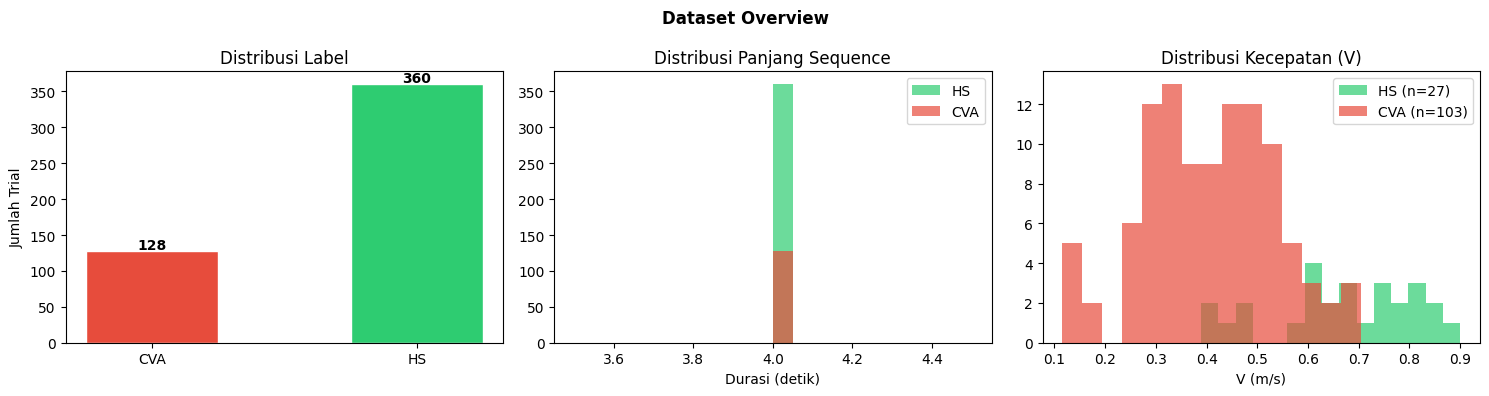

✅ Saved -> data_overview.png (local)


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Dataset Overview", fontsize=12, fontweight="bold")

# 1. Label distribution
ax = axes[0]
labels, counts = np.unique(labels_str, return_counts=True)
colors = ["#e74c3c" if l=="CVA" else "#2ecc71" for l in labels]
bars = ax.bar(labels, counts, color=colors, edgecolor="white", width=0.5)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, c+3, str(c), ha="center", fontweight="bold")
ax.set_title("Distribusi Label")
ax.set_ylabel("Jumlah Trial")

# 2. Sequence length distribution (actual non-zero length)
ax = axes[1]
actual_lens = []
for i in range(len(X_ts)):
    norms = np.linalg.norm(X_ts[i], axis=1)
    nz    = np.where(norms > 1e-4)[0]
    actual_lens.append(len(nz) if len(nz)>0 else T_MAX)
actual_lens = np.array(actual_lens)
for lbl, name, color in [(0,"HS","#2ecc71"),(1,"CVA","#e74c3c")]:
    ax.hist(actual_lens[y_all==lbl]/FS, bins=20, alpha=0.7, label=name, color=color)
ax.set_title("Distribusi Panjang Sequence")
ax.set_xlabel("Durasi (detik)")
ax.legend()

# 3. Velocity distribution
ax = axes[2]
v_col = "V"
if v_col in df_semi_ts.columns:
    for lbl, name, color in [(0,"HS","#2ecc71"),(1,"CVA","#e74c3c")]:
        v = df_semi_ts[v_col][y_all==lbl].dropna()
        ax.hist(v, bins=15, alpha=0.7, label=f"{name} (n={len(v)})", color=color)
    ax.set_title("Distribusi Kecepatan (V)")
    ax.set_xlabel("V (m/s)")
    ax.legend()

plt.tight_layout()
plt.savefig("data_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved -> data_overview.png (local)")

---
## TAHAP 7 -- ARSITEKTUR MODEL: Hybrid BiTCN-BiGRU-Cross Attention + Semiogram MLP

### Desain Arsitektur

```
Input Time-Series (N, T, 6)
    |
    Split: Acc (N, T, 3) | Gyr (N, T, 3)
    |                       |
    BiTCN                  BiTCN
    (dilated conv, 3 lyr)  (dilated conv, 3 lyr)
    |                       |
    BiGRU                  BiGRU
    |                       |
    z_acc (N, D)           z_gyr (N, D)
    |                       |
    Cross Attention: Acc (Q) x Gyr (K,V)
    |
    z_ts (N, 2D)
    |
    Input Semiogram (N, F)
    |
    MLP: F -> 32 -> 16
    |
    z_semi (N, 16)
    |
    Fusion: z_ts || z_semi -> FC -> Dropout -> output logit
```

**Catatan overfitting pada dataset kecil:**
- Model kecil (hidden=32)
- Dropout=0.3 di semua tahap
- Early stopping patience=10
- Weight decay=1e-4
- WeightedRandomSampler untuk imbalance CVA/HS


In [32]:
class TCNResidualBlock(nn.Module):
    """Satu residual block BiTCN: forward + backward dilated conv."""
    def __init__(self, in_ch, out_ch, kernel=3, dilation=1, dropout=0.2):
        super().__init__()
        pad = (kernel - 1) * dilation
        # Forward (causal) conv
        self.conv_fwd = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        # Backward (anti-causal): flip time dimension
        self.conv_bwd = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        # Fuse bi-directional
        self.fuse = nn.Conv1d(out_ch*2, out_ch, 1)
        # Residual projection
        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        # x: (B, C, T)
        fwd = self.conv_fwd(x)[:, :, :x.size(2)]   # causal trim
        bwd = self.conv_bwd(torch.flip(x, dims=[2]))
        bwd = torch.flip(bwd, dims=[2])[:, :, :x.size(2)]
        bi  = self.fuse(torch.cat([fwd, bwd], dim=1))
        return F.gelu(bi + self.residual(x))


class BiTCN(nn.Module):
    def __init__(self, in_ch, hidden=32, n_layers=3, kernel=3, dropout=0.2):
        super().__init__()
        layers = []
        ch = in_ch
        for i in range(n_layers):
            layers.append(TCNResidualBlock(ch, hidden, kernel, dilation=2**i, dropout=dropout))
            ch = hidden
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, T, C) -> (B, C, T)
        return self.net(x.permute(0,2,1)).permute(0,2,1)  # -> (B, T, hidden)


class SemiogramMLP(nn.Module):
    def __init__(self, in_dim, hidden=32, out_dim=16, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class HybridCVAModel(nn.Module):
    """
    Hybrid BiTCN-BiGRU-Cross Attention + Semiogram MLP.
    Input:
      x_ts    : (B, T, 6)  -- first 3 = Acc, last 3 = Gyr
      x_semi  : (B, F)     -- semiogram features
    Output:
      logit   : (B, 1)
    """
    def __init__(self, n_semi, T=400, hidden=32, n_layers=3,
                 n_heads=2, dropout=0.3):
        super().__init__()
        self.hidden = hidden

        # Time-series branches
        self.tcn_acc = BiTCN(3, hidden, n_layers, dropout=dropout)
        self.tcn_gyr = BiTCN(3, hidden, n_layers, dropout=dropout)

        self.gru_acc = nn.GRU(hidden, hidden, batch_first=True,
                               bidirectional=True, num_layers=1)
        self.gru_gyr = nn.GRU(hidden, hidden, batch_first=True,
                               bidirectional=True, num_layers=1)

        # Cross attention: acc (Q) attends to gyr (K,V)
        # d_model = 2*hidden (bidirectional GRU output)
        d_model = hidden * 2
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.attn_norm = nn.LayerNorm(d_model)

        # Semiogram branch
        self.semi_mlp = SemiogramMLP(n_semi, hidden=32, out_dim=16, dropout=dropout)

        # Fusion head
        fusion_in = d_model * 2 + 16  # acc_emb + gyr_emb + semi_emb
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

        # Store attention weights for visualization
        self._attn_weights = None

    def forward(self, x_ts, x_semi):
        # Split channels
        acc = x_ts[:, :, :3]  # (B, T, 3)
        gyr = x_ts[:, :, 3:]  # (B, T, 3)

        # BiTCN
        acc_feat = self.tcn_acc(acc)  # (B, T, hidden)
        gyr_feat = self.tcn_gyr(gyr)

        # BiGRU
        acc_gru, _ = self.gru_acc(acc_feat)  # (B, T, 2*hidden)
        gyr_gru, _ = self.gru_gyr(gyr_feat)

        # Cross Attention: Acc as Query, Gyr as Key/Value
        attn_out, attn_w = self.cross_attn(acc_gru, gyr_gru, gyr_gru)
        self._attn_weights = attn_w.detach()
        acc_out = self.attn_norm(acc_gru + attn_out)

        # Global average pooling over time
        z_acc = acc_out.mean(dim=1)   # (B, 2*hidden)
        z_gyr = gyr_gru.mean(dim=1)   # (B, 2*hidden)

        # Semiogram branch
        z_semi = self.semi_mlp(x_semi)  # (B, 16)

        # Fusion
        z = torch.cat([z_acc, z_gyr, z_semi], dim=1)
        return self.fusion(z)  # (B, 1)


# Test instantiation
n_semi = X_semi.shape[1]
model_test = HybridCVAModel(n_semi=n_semi, T=T_MAX, hidden=32, n_layers=3, n_heads=2)
x_ts_t  = torch.zeros(4, T_MAX, 6)
x_semi_t= torch.zeros(4, n_semi)
out = model_test(x_ts_t, x_semi_t)
total_params = sum(p.numel() for p in model_test.parameters())
print(f"✅ Model output shape: {out.shape}")
print(f"✅ Total parameters : {total_params:,}")
del model_test

✅ Model output shape: torch.Size([4, 1])
✅ Total parameters : 94,449


---
## TAHAP 8 -- BASELINE: Semiogram + RF/SVM/XGBoost

Baseline ini digunakan untuk membandingkan:
1. **Handcrafted only** (semiogram + RF/SVM) -- ini baseline
2. **Time-series only** (BiTCN-BiGRU-CA, ablation)
3. **Hybrid** (time-series + semiogram) -- model utama

**Ekspektasi:** Hybrid > TS-only >= Semiogram-only, dan Cross Attention > tanpa CA.


In [33]:
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics         import accuracy_score, balanced_accuracy_score, roc_auc_score
from xgboost                 import XGBClassifier

pipe_rf = Pipeline([
    ("imp",   SimpleImputer(strategy="median")),
    ("scl",   StandardScaler()),
    ("clf",   RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                     random_state=SEED, n_jobs=-1)),
])
pipe_svm = Pipeline([
    ("imp",   SimpleImputer(strategy="median")),
    ("scl",   StandardScaler()),
    ("clf",   SVC(kernel="rbf", C=10, gamma="scale",
                  class_weight="balanced", probability=True, random_state=SEED)),
])
pipe_xgb = Pipeline([
    ("imp",   SimpleImputer(strategy="median")),
    ("scl",   StandardScaler()),
    ("clf",   XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                             scale_pos_weight=(y_all==0).sum()/(y_all==1).sum(),
                             eval_metric="logloss", random_state=SEED, verbosity=0)),
])

n_splits = min(5, pd.Series(g_all).nunique())
gkf      = GroupKFold(n_splits=n_splits)

baseline_results = {}
for name, pipe in [("RF", pipe_rf), ("SVM", pipe_svm), ("XGBoost", pipe_xgb)]:
    print(f"  Training {name}...")
    y_pred = cross_val_predict(pipe, X_semi, y_all, groups=g_all, cv=gkf, method="predict")
    y_prob = cross_val_predict(pipe, X_semi, y_all, groups=g_all, cv=gkf, method="predict_proba")[:,1]
    acc  = accuracy_score(y_all, y_pred)
    bacc = balanced_accuracy_score(y_all, y_pred)
    auc  = roc_auc_score(y_all, y_prob)
    baseline_results[name] = {"acc":acc,"bacc":bacc,"auc":auc,"pred":y_pred,"prob":y_prob}
    print(f"  {name}: Acc={acc:.4f} | Balanced Acc={bacc:.4f} | ROC-AUC={auc:.4f}")

print("\n✅ Baseline selesai.")

  Training RF...
  RF: Acc=0.9098 | Balanced Acc=0.8558 | ROC-AUC=0.8312
  Training SVM...
  SVM: Acc=0.8975 | Balanced Acc=0.8475 | ROC-AUC=0.8283
  Training XGBoost...
  XGBoost: Acc=0.9078 | Balanced Acc=0.8595 | ROC-AUC=0.8087

✅ Baseline selesai.


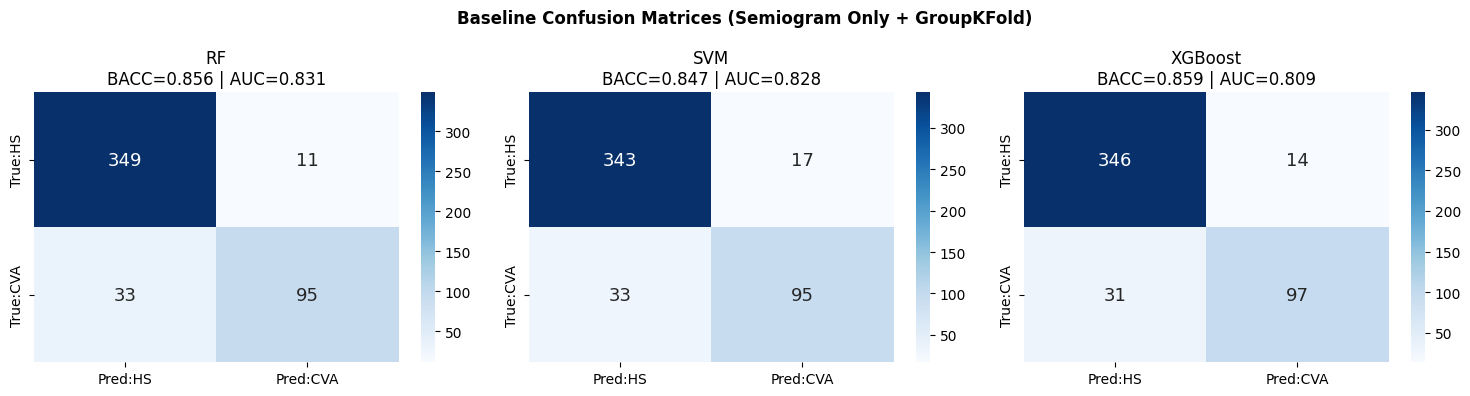

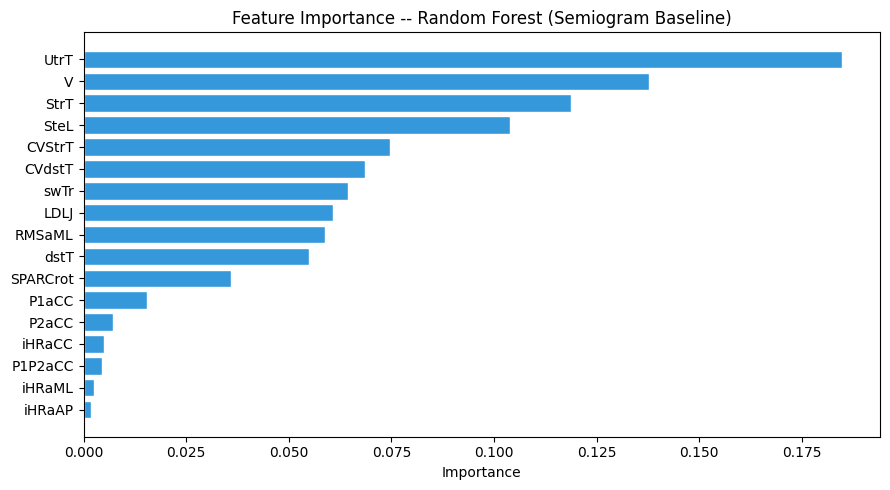

✅ Saved baseline plots (local)


In [34]:
# Confusion matrices baseline
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Baseline Confusion Matrices (Semiogram Only + GroupKFold)", fontsize=12, fontweight="bold")

for ax, (name, res) in zip(axes, baseline_results.items()):
    cm = confusion_matrix(y_all, res["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred:HS","Pred:CVA"],
                yticklabels=["True:HS","True:CVA"],
                annot_kws={"size":13})
    ax.set_title(f"{name}\nBACC={res['bacc']:.3f} | AUC={res['auc']:.3f}")

plt.tight_layout()
plt.savefig("baseline_cm.png", dpi=120, bbox_inches="tight")
plt.show()

# Feature importance RF
pipe_rf.fit(X_semi, y_all)
fi = pipe_rf["clf"].feature_importances_
fi_df = pd.DataFrame({"param": SEMI_PARAMS, "importance": fi}).sort_values("importance")
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(fi_df["param"], fi_df["importance"], color="#3498db", edgecolor="white")
ax.set_title("Feature Importance -- Random Forest (Semiogram Baseline)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved baseline plots (local)")

---
## TAHAP 9 -- TRAINING UTILITIES & LOOP

In [35]:
def make_scaler_imputer_ts(X_train):
    """Fit StandardScaler per channel pada X_train (N,T,C)."""
    N, T, C = X_train.shape
    scaler_ts = StandardScaler()
    X_flat = X_train.reshape(-1, C)
    scaler_ts.fit(X_flat)
    return scaler_ts

def apply_scaler_ts(X, scaler):
    N, T, C = X.shape
    X_flat = X.reshape(-1, C)
    return scaler.transform(X_flat).reshape(N, T, C)

def make_scaler_semi(X_train):
    imp = SimpleImputer(strategy="median")
    scl = StandardScaler()
    X_imp = imp.fit_transform(X_train)
    scl.fit(X_imp)
    return imp, scl

def apply_scaler_semi(X, imp, scl):
    return scl.transform(imp.transform(X))


class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float("inf")
        self.counter    = 0
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.cpu().clone()
                               for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience


def train_one_fold(X_ts_tr, X_semi_tr, y_tr,
                   X_ts_va, X_semi_va, y_va,
                   n_semi, device,
                   n_epochs=60, batch_size=32, lr=1e-3,
                   hidden=32, n_layers=3, n_heads=2, dropout=0.3,
                   weight_decay=1e-4, patience=12):
    """Train model for one fold, return best model + history."""

    # Scale
    scaler_ts = make_scaler_imputer_ts(X_ts_tr)
    imp_s, scl_s = make_scaler_semi(X_semi_tr)

    Xts_tr  = apply_scaler_ts(X_ts_tr,  scaler_ts).astype(np.float32)
    Xts_va  = apply_scaler_ts(X_ts_va,  scaler_ts).astype(np.float32)
    Xsm_tr  = apply_scaler_semi(X_semi_tr, imp_s, scl_s).astype(np.float32)
    Xsm_va  = apply_scaler_semi(X_semi_va, imp_s, scl_s).astype(np.float32)

    Xts_tr_t  = torch.from_numpy(Xts_tr)
    Xts_va_t  = torch.from_numpy(Xts_va)
    Xsm_tr_t  = torch.from_numpy(Xsm_tr)
    Xsm_va_t  = torch.from_numpy(Xsm_va)
    y_tr_t    = torch.FloatTensor(y_tr).unsqueeze(1)
    y_va_t    = torch.FloatTensor(y_va).unsqueeze(1)

    # WeightedRandomSampler
    n_pos = y_tr.sum(); n_neg = len(y_tr) - n_pos
    w_pos = len(y_tr) / (2 * max(n_pos, 1))
    w_neg = len(y_tr) / (2 * max(n_neg, 1))
    sample_weights = torch.FloatTensor(
        [w_pos if y==1 else w_neg for y in y_tr]
    )
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

    ds_tr = TensorDataset(Xts_tr_t, Xsm_tr_t, y_tr_t)
    ds_va = TensorDataset(Xts_va_t, Xsm_va_t, y_va_t)
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, sampler=sampler)
    dl_va = DataLoader(ds_va, batch_size=batch_size)

    model = HybridCVAModel(n_semi=n_semi, T=X_ts_tr.shape[1],
                            hidden=hidden, n_layers=n_layers,
                            n_heads=n_heads, dropout=dropout).to(device)

    pos_weight = torch.FloatTensor([n_neg / max(n_pos, 1)]).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    es         = EarlyStopping(patience=patience)

    history = {"train_loss":[], "val_loss":[], "val_auc":[]}

    for epoch in range(n_epochs):
        # Train
        model.train()
        train_loss = 0.0
        for xts_b, xsm_b, y_b in dl_tr:
            xts_b = xts_b.to(device)
            xsm_b = xsm_b.to(device)
            y_b   = y_b.to(device)
            optimizer.zero_grad()
            out  = model(xts_b, xsm_b)
            loss = criterion(out, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * len(y_b)
        train_loss /= len(dl_tr.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        all_probs, all_true = [], []
        with torch.no_grad():
            for xts_b, xsm_b, y_b in dl_va:
                xts_b = xts_b.to(device)
                xsm_b = xsm_b.to(device)
                y_b   = y_b.to(device)
                out   = model(xts_b, xsm_b)
                val_loss += criterion(out, y_b).item() * len(y_b)
                all_probs.extend(torch.sigmoid(out).cpu().numpy().flatten())
                all_true.extend(y_b.cpu().numpy().flatten())
        val_loss /= len(dl_va.dataset)
        try:
            val_auc = roc_auc_score(all_true, all_probs)
        except Exception:
            val_auc = 0.5

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)

        scheduler.step()

        if es(val_loss, model):
            break

    # Restore best
    if es.best_state:
        model.load_state_dict(es.best_state)

    return model, history, scaler_ts, imp_s, scl_s


print("✅ Training utilities siap.")

✅ Training utilities siap.


---
## TAHAP 10 -- TRAINING HYBRID MODEL (GroupKFold by Subject)

**Mengapa GroupKFold?**
Dataset memiliki 2-16 trial per subjek. Jika trial dari subjek yang sama masuk ke train dan test, model hanya belajar "mengenali subjek", bukan pola patologis CVA. GroupKFold memastikan semua trial dari satu subjek hanya ada di satu fold.


In [36]:
N_SPLITS = min(5, pd.Series(g_all).nunique())
gkf      = GroupKFold(n_splits=N_SPLITS)

print(f"✅ {N_SPLITS}-fold GroupKFold")
print(f"✅ n_semi = {n_semi}")

all_fold_results = []
all_oof_probs    = np.zeros(len(y_all))
all_oof_preds    = np.zeros(len(y_all))

EPOCHS  = 60
HIDDEN  = 32
LAYERS  = 3
HEADS   = 2
DROPOUT = 0.3
LR      = 1e-3
BATCH   = 32

fold_histories = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_ts, y_all, groups=g_all)):
    print(f"\n{'='*55}")
    print(f" Fold {fold+1}/{N_SPLITS} | Train={len(tr_idx)} Val={len(va_idx)}")
    print(f"{'='*55}")

    X_ts_tr, X_ts_va   = X_ts[tr_idx],   X_ts[va_idx]
    X_sm_tr, X_sm_va   = X_semi[tr_idx], X_semi[va_idx]
    y_tr, y_va         = y_all[tr_idx],   y_all[va_idx]

    model_fold, hist, sc_ts, imp_s, sc_s = train_one_fold(
        X_ts_tr, X_sm_tr, y_tr,
        X_ts_va, X_sm_va, y_va,
        n_semi=n_semi, device=DEVICE,
        n_epochs=EPOCHS, batch_size=BATCH, lr=LR,
        hidden=HIDDEN, n_layers=LAYERS, n_heads=HEADS,
        dropout=DROPOUT, patience=12
    )
    fold_histories.append(hist)

    # OOF predictions
    model_fold.eval()
    Xts_va_sc = apply_scaler_ts(X_ts_va, sc_ts).astype(np.float32)
    Xsm_va_sc = apply_scaler_semi(X_sm_va, imp_s, sc_s).astype(np.float32)
    with torch.no_grad():
        logits = model_fold(
            torch.FloatTensor(Xts_va_sc).to(DEVICE),
            torch.FloatTensor(Xsm_va_sc).to(DEVICE)
        ).cpu().numpy().flatten()
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    all_oof_probs[va_idx] = probs
    all_oof_preds[va_idx] = preds

    acc  = accuracy_score(y_va, preds)
    bacc = balanced_accuracy_score(y_va, preds)
    auc  = roc_auc_score(y_va, probs) if len(np.unique(y_va))>1 else 0.5

    fold_res = {"fold":fold+1, "acc":acc, "bacc":bacc, "auc":auc,
                "best_val_loss": min(hist["val_loss"]),
                "n_epochs": len(hist["train_loss"])}
    all_fold_results.append(fold_res)

    print(f"  Acc={acc:.4f} | BalAcc={bacc:.4f} | AUC={auc:.4f} | Epochs={fold_res['n_epochs']}")

print("\n" + "="*55)
print(" HASIL KESELURUHAN (OOF Hybrid Model)")
print("="*55)
oof_acc  = accuracy_score(y_all, all_oof_preds)
oof_bacc = balanced_accuracy_score(y_all, all_oof_preds)
oof_auc  = roc_auc_score(y_all, all_oof_probs)
print(f"  Accuracy         : {oof_acc:.4f}")
print(f"  Balanced Accuracy: {oof_bacc:.4f}")
print(f"  ROC-AUC          : {oof_auc:.4f}")
print()
print(classification_report(y_all, all_oof_preds, target_names=["HS","CVA"]))

✅ 5-fold GroupKFold
✅ n_semi = 17

 Fold 1/5 | Train=391 Val=97
  Acc=0.9381 | BalAcc=0.8877 | AUC=0.9383 | Epochs=24

 Fold 2/5 | Train=390 Val=98
  Acc=0.7041 | BalAcc=0.7085 | AUC=0.8262 | Epochs=19

 Fold 3/5 | Train=390 Val=98
  Acc=0.9388 | BalAcc=0.9195 | AUC=0.9710 | Epochs=21

 Fold 4/5 | Train=390 Val=98
  Acc=0.9184 | BalAcc=0.9316 | AUC=0.9803 | Epochs=41

 Fold 5/5 | Train=391 Val=97
  Acc=0.9175 | BalAcc=0.9129 | AUC=0.9411 | Epochs=25

 HASIL KESELURUHAN (OOF Hybrid Model)
  Accuracy         : 0.8832
  Balanced Accuracy: 0.8705
  ROC-AUC          : 0.9413

              precision    recall  f1-score   support

          HS       0.94      0.90      0.92       360
         CVA       0.74      0.84      0.79       128

    accuracy                           0.88       488
   macro avg       0.84      0.87      0.86       488
weighted avg       0.89      0.88      0.89       488



---
## TAHAP 11 -- EVALUASI & VISUALISASI

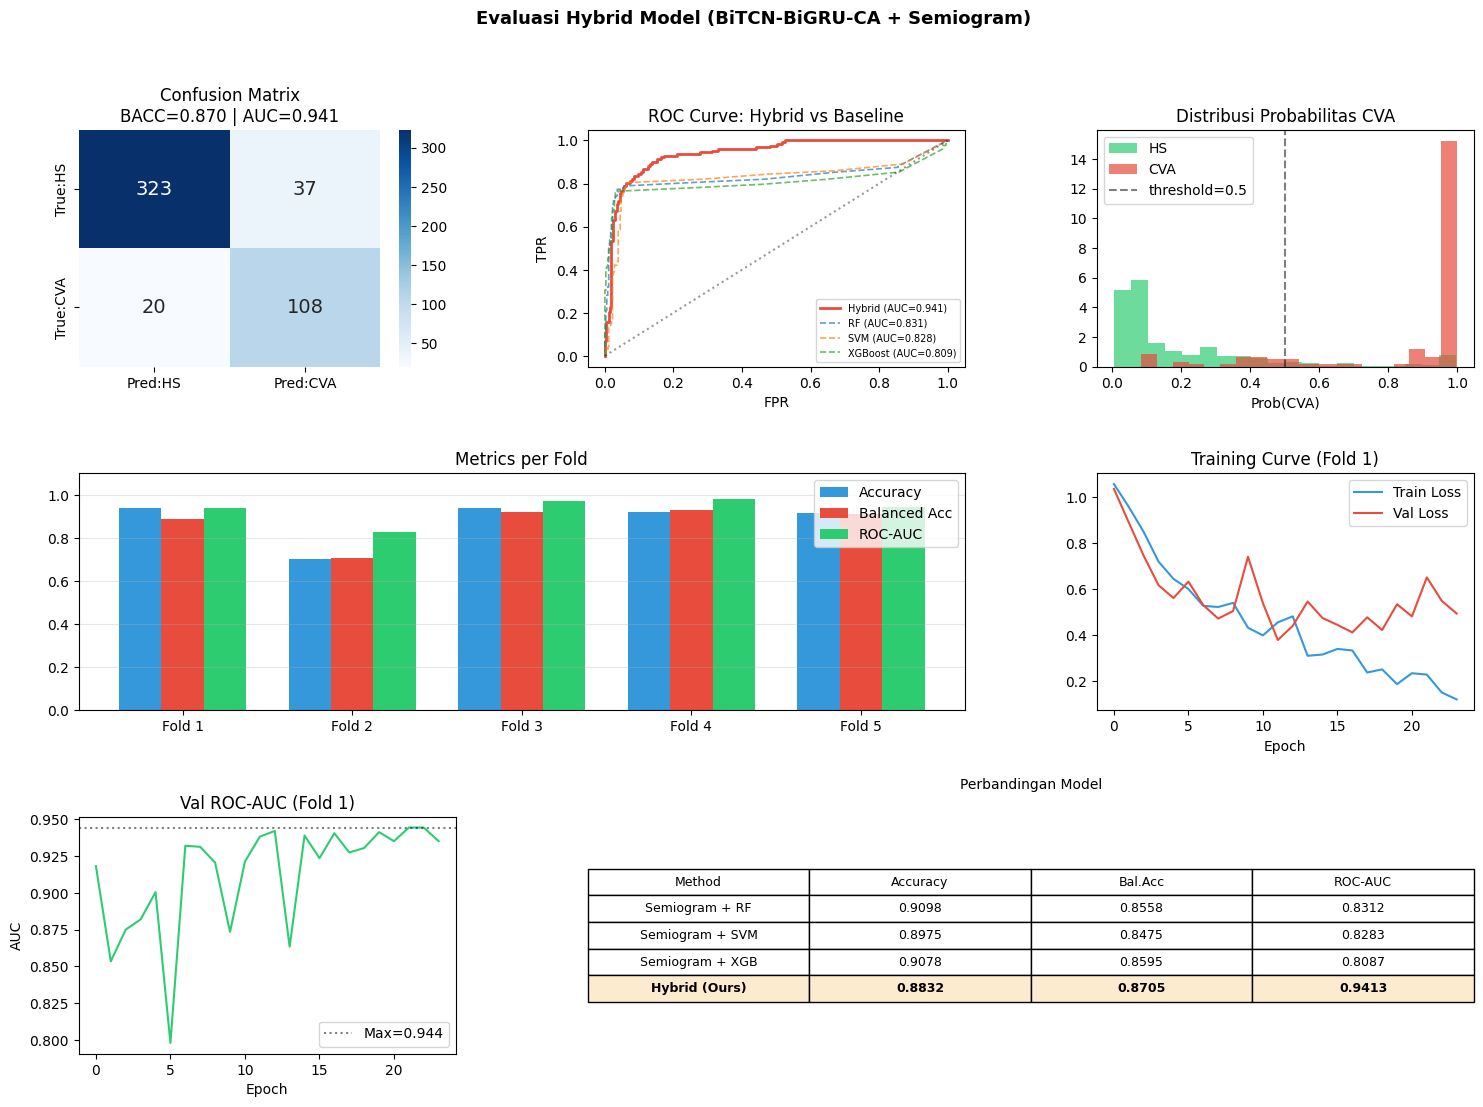

✅ Saved -> hybrid_eval.png (local)


In [ ]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Evaluasi Hybrid Model (BiTCN-BiGRU-CA + Semiogram)", fontsize=13, fontweight="bold")

# 1. Confusion Matrix
ax = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_all, all_oof_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred:HS","Pred:CVA"],
            yticklabels=["True:HS","True:CVA"],
            annot_kws={"size":14})
ax.set_title(f"Confusion Matrix\nBACC={oof_bacc:.3f} | AUC={oof_auc:.3f}")

# 2. ROC Curve
ax = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_all, all_oof_probs)
ax.plot(fpr, tpr, color="#e74c3c", linewidth=2, label=f"Hybrid (AUC={oof_auc:.3f})")
for name, res in baseline_results.items():
    fpr_b, tpr_b, _ = roc_curve(y_all, res["prob"])
    ax.plot(fpr_b, tpr_b, linestyle="--", alpha=0.7, linewidth=1.2,
            label=f"{name} (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1], "k:", alpha=0.4)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curve: Hybrid vs Baseline")
ax.legend(fontsize=7)

# 3. Probability Distribution
ax = fig.add_subplot(gs[0, 2])
for lbl, name, color in [(0,"HS","#2ecc71"),(1,"CVA","#e74c3c")]:
    ax.hist(all_oof_probs[y_all==lbl], bins=20, alpha=0.7,
            label=name, color=color, density=True)
ax.axvline(0.5, color="k", linestyle="--", alpha=0.5, label="threshold=0.5")
ax.set_title("Distribusi Probabilitas CVA")
ax.set_xlabel("Prob(CVA)")
ax.legend()

# 4. Fold metrics bar
ax = fig.add_subplot(gs[1, 0:2])
folds = [r["fold"] for r in all_fold_results]
accs  = [r["acc"]  for r in all_fold_results]
baccs = [r["bacc"] for r in all_fold_results]
aucs  = [r["auc"]  for r in all_fold_results]
x     = np.arange(len(folds))
w     = 0.25
ax.bar(x-w, accs,  w, label="Accuracy",      color="#3498db")
ax.bar(x,   baccs, w, label="Balanced Acc",  color="#e74c3c")
ax.bar(x+w, aucs,  w, label="ROC-AUC",       color="#2ecc71")
ax.set_xticks(x); ax.set_xticklabels([f"Fold {f}" for f in folds])
ax.set_ylim(0, 1.1)
ax.set_title("Metrics per Fold")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# 5. Training loss curve (fold 1)
ax = fig.add_subplot(gs[1, 2])
hist0 = fold_histories[0]
ax.plot(hist0["train_loss"], label="Train Loss", color="#3498db")
ax.plot(hist0["val_loss"],   label="Val Loss",   color="#e74c3c")
ax.set_title("Training Curve (Fold 1)")
ax.set_xlabel("Epoch"); ax.legend()

# 6. Validation AUC curve (fold 1)
ax = fig.add_subplot(gs[2, 0])
ax.plot(hist0["val_auc"], color="#2ecc71")
ax.set_title("Val ROC-AUC (Fold 1)")
ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
ax.axhline(max(hist0["val_auc"]), color="k", linestyle=":", alpha=0.5,
           label=f"Max={max(hist0['val_auc']):.3f}")
ax.legend()

# 7. Comparison table
ax = fig.add_subplot(gs[2, 1:])
ax.axis("off")
methods = ["Semiogram + RF", "Semiogram + SVM", "Semiogram + XGB", "Hybrid (Ours)"]
acc_vals  = [baseline_results["RF"]["acc"], baseline_results["SVM"]["acc"],
             baseline_results["XGBoost"]["acc"], oof_acc]
bacc_vals = [baseline_results["RF"]["bacc"], baseline_results["SVM"]["bacc"],
             baseline_results["XGBoost"]["bacc"], oof_bacc]
auc_vals  = [baseline_results["RF"]["auc"],  baseline_results["SVM"]["auc"],
             baseline_results["XGBoost"]["auc"],  oof_auc]

table_data = [[m, f"{a:.4f}", f"{b:.4f}", f"{u:.4f}"]
              for m,a,b,u in zip(methods, acc_vals, bacc_vals, auc_vals)]
tbl = ax.table(cellText=table_data,
               colLabels=["Method", "Accuracy", "Bal.Acc", "ROC-AUC"],
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
# Highlight hybrid row
for j in range(4):
    tbl[(4,j)].set_facecolor("#fdebd0")
    tbl[(4,j)].set_text_props(fontweight="bold")
ax.set_title("Perbandingan Model", fontsize=10, pad=20)

plt.savefig("hybrid_eval.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved -> hybrid_eval.png (local)")

---
## TAHAP 12 -- ABLATION STUDY

**Tujuan:** Membuktikan kontribusi masing-masing komponen.

| Eksperimen | Input TS | Komponen |
|---|---|---|
| 1 | - | Semiogram-only baseline (RF) |
| 2 | LB Acc+Gyr | TS-only (tanpa semiogram) |
| 3 | LB Acc+Gyr | Hybrid (semiogram + TS) -- model utama |
| 4 | LB Acc only | Acc-only stream |
| 5 | LB Gyr only | Gyr-only stream |
| 6 | LB Acc+Gyr | Tanpa Cross Attention |
| 7 | LB Acc+Gyr | Dengan Cross Attention (model utama) |


In [ ]:
import time

class HybridCVAModelAblation(nn.Module):
    """Versi ablation dengan kontrol: no_semi, acc_only, gyr_only, no_attn."""
    def __init__(self, n_semi, T=400, hidden=32, n_layers=3,
                 n_heads=2, dropout=0.3,
                 use_semi=True, use_acc=True, use_gyr=True, use_attn=True):
        super().__init__()

        self.use_semi = use_semi
        self.use_acc  = use_acc
        self.use_gyr  = use_gyr
        self.use_attn = use_attn

        if use_acc:
            self.tcn_acc = BiTCN(3, hidden, n_layers, dropout=dropout)
            self.gru_acc = nn.GRU(hidden, hidden, batch_first=True, bidirectional=True)

        if use_gyr:
            self.tcn_gyr = BiTCN(3, hidden, n_layers, dropout=dropout)
            self.gru_gyr = nn.GRU(hidden, hidden, batch_first=True, bidirectional=True)

        if use_attn and use_acc and use_gyr:
            d_model = hidden * 2
            self.cross_attn = nn.MultiheadAttention(
                d_model, n_heads, dropout=dropout, batch_first=True
            )
            self.attn_norm = nn.LayerNorm(d_model)

        d_ts = 0
        if use_acc:
            d_ts += hidden * 2
        if use_gyr:
            d_ts += hidden * 2

        d_semi = 16 if use_semi else 0

        if use_semi:
            self.semi_mlp = SemiogramMLP(n_semi, 32, 16, dropout)

        self.fusion = nn.Sequential(
            nn.Linear(d_ts + d_semi, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x_ts, x_semi):
        parts = []

        acc_gru = None
        gyr_gru = None

        if self.use_acc:
            acc = x_ts[:, :, :3]
            acc_feat = self.tcn_acc(acc)
            acc_gru, _ = self.gru_acc(acc_feat)

        if self.use_gyr:
            gyr = x_ts[:, :, 3:]
            gyr_feat = self.tcn_gyr(gyr)
            gyr_gru, _ = self.gru_gyr(gyr_feat)

        if self.use_attn and self.use_acc and self.use_gyr:
            attn_out, _ = self.cross_attn(acc_gru, gyr_gru, gyr_gru)
            acc_gru = self.attn_norm(acc_gru + attn_out)

        if self.use_acc:
            parts.append(acc_gru.mean(dim=1))

        if self.use_gyr:
            parts.append(gyr_gru.mean(dim=1))

        if parts:
            z_ts = torch.cat(parts, dim=1)
        else:
            z_ts = torch.zeros(x_ts.size(0), 1).to(x_ts.device)

        if self.use_semi:
            z_semi = self.semi_mlp(x_semi)
            z_ts = torch.cat([z_ts, z_semi], dim=1)

        return self.fusion(z_ts)


def run_ablation(config_name, use_semi, use_acc, use_gyr, use_attn,
                 n_epochs=40, patience=10):
    """Run one ablation config with GroupKFold + visible progress."""

    print(f"\n==============================", flush=True)
    print(f"Running config: {config_name}", flush=True)
    print(f"==============================", flush=True)

    start_config = time.time()

    probs_oof = np.zeros(len(y_all))
    preds_oof = np.zeros(len(y_all))

    n_folds = gkf.get_n_splits(X_ts, y_all, groups=g_all)

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_ts, y_all, groups=g_all)):
        start_fold = time.time()

        print(f"\n[{config_name}] Fold {fold + 1}/{n_folds} mulai...", flush=True)

        X_ts_tr, X_ts_va = X_ts[tr_idx], X_ts[va_idx]
        X_sm_tr, X_sm_va = X_semi[tr_idx], X_semi[va_idx]
        y_tr, y_va = y_all[tr_idx], y_all[va_idx]

        sc_ts = make_scaler_imputer_ts(X_ts_tr)
        imp_s, sc_s = make_scaler_semi(X_sm_tr)

        Xts_tr = apply_scaler_ts(X_ts_tr, sc_ts).astype(np.float32)
        Xts_va = apply_scaler_ts(X_ts_va, sc_ts).astype(np.float32)
        Xsm_tr = apply_scaler_semi(X_sm_tr, imp_s, sc_s).astype(np.float32)
        Xsm_va = apply_scaler_semi(X_sm_va, imp_s, sc_s).astype(np.float32)

        model = HybridCVAModelAblation(
            n_semi=n_semi,
            T=T_MAX,
            hidden=HIDDEN,
            n_layers=LAYERS,
            n_heads=HEADS,
            dropout=DROPOUT,
            use_semi=use_semi,
            use_acc=use_acc,
            use_gyr=use_gyr,
            use_attn=use_attn
        ).to(DEVICE)

        n_pos = y_tr.sum()
        n_neg = len(y_tr) - n_pos
        pos_w = torch.FloatTensor([n_neg / max(n_pos, 1)]).to(DEVICE)

        crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)
        opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

        ds_tr = TensorDataset(
            torch.FloatTensor(Xts_tr),
            torch.FloatTensor(Xsm_tr),
            torch.FloatTensor(y_tr).unsqueeze(1)
        )

        dl_tr = DataLoader(
            ds_tr,
            batch_size=BATCH,
            shuffle=True
        )

        es = EarlyStopping(patience=patience)

        for epoch in range(n_epochs):
            model.train()
            train_losses = []

            for xb, sb, yb in dl_tr:
                xb = xb.to(DEVICE)
                sb = sb.to(DEVICE)
                yb = yb.to(DEVICE)

                opt.zero_grad()
                logits = model(xb, sb)
                loss = crit(logits, yb)
                loss.backward()

                nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                opt.step()
                train_losses.append(loss.item())

            model.eval()
            with torch.no_grad():
                Xva_tensor = torch.FloatTensor(Xts_va).to(DEVICE)
                Sva_tensor = torch.FloatTensor(Xsm_va).to(DEVICE)
                yva_tensor = torch.FloatTensor(y_va).unsqueeze(1).to(DEVICE)

                val_logits = model(Xva_tensor, Sva_tensor)
                vl = crit(val_logits, yva_tensor).item()

            train_loss = float(np.mean(train_losses))

            print(
                f"[{config_name}] Fold {fold + 1}/{n_folds} | "
                f"Epoch {epoch + 1:02d}/{n_epochs} | "
                f"train_loss={train_loss:.4f} | val_loss={vl:.4f}",
                flush=True
            )

            if es(vl, model):
                print(
                    f"[{config_name}] Fold {fold + 1} early stopped "
                    f"at epoch {epoch + 1}",
                    flush=True
                )
                break

        if es.best_state:
            model.load_state_dict(es.best_state)

        model.eval()
        with torch.no_grad():
            logits = model(
                torch.FloatTensor(Xts_va).to(DEVICE),
                torch.FloatTensor(Xsm_va).to(DEVICE)
            ).cpu().numpy().flatten()

        p = 1 / (1 + np.exp(-logits))

        probs_oof[va_idx] = p
        preds_oof[va_idx] = (p >= 0.5).astype(int)

        fold_acc = accuracy_score(y_va, preds_oof[va_idx])
        fold_bacc = balanced_accuracy_score(y_va, preds_oof[va_idx])

        try:
            fold_auc = roc_auc_score(y_va, probs_oof[va_idx])
        except ValueError:
            fold_auc = np.nan

        fold_time = time.time() - start_fold

        print(
            f"[{config_name}] Fold {fold + 1}/{n_folds} selesai | "
            f"Acc={fold_acc:.3f} | BACC={fold_bacc:.3f} | "
            f"AUC={fold_auc:.3f} | time={fold_time/60:.1f} min",
            flush=True
        )

    acc = accuracy_score(y_all, preds_oof)
    bacc = balanced_accuracy_score(y_all, preds_oof)
    auc = roc_auc_score(y_all, probs_oof)

    config_time = time.time() - start_config

    print(
        f"\nFINAL {config_name:35s}: "
        f"Acc={acc:.3f} | BACC={bacc:.3f} | AUC={auc:.3f} | "
        f"time={config_time/60:.1f} min",
        flush=True
    )

    return {
        "name": config_name,
        "acc": acc,
        "bacc": bacc,
        "auc": auc,
        "time_min": config_time / 60
    }


print("Running ablation study...", flush=True)

ablation_results = []

ablation_results.append({
    "name": "Semiogram-only (RF)",
    "acc": baseline_results["RF"]["acc"],
    "bacc": baseline_results["RF"]["bacc"],
    "auc": baseline_results["RF"]["auc"],
    "time_min": np.nan
})

print(
    f"  {'Semiogram-only (RF)':35s}: "
    f"Acc={ablation_results[0]['acc']:.3f} | "
    f"BACC={ablation_results[0]['bacc']:.3f} | "
    f"AUC={ablation_results[0]['auc']:.3f}",
    flush=True
)

ablation_results.append(
    run_ablation(
        "TS-only (no semiogram)",
        use_semi=False,
        use_acc=True,
        use_gyr=True,
        use_attn=True,
        n_epochs=40,
        patience=10
    )
)

ablation_results.append({
    "name": "Hybrid (Acc+Gyr+Semi) [Main]",
    "acc": oof_acc,
    "bacc": oof_bacc,
    "auc": oof_auc,
    "time_min": np.nan
})

print(
    f"  {'Hybrid (Acc+Gyr+Semi) [Main]':35s}: "
    f"Acc={oof_acc:.3f} | BACC={oof_bacc:.3f} | AUC={oof_auc:.3f}",
    flush=True
)

ablation_results.append(
    run_ablation(
        "Acc-only (no Gyr, +semi)",
        use_semi=True,
        use_acc=True,
        use_gyr=False,
        use_attn=False,
        n_epochs=40,
        patience=10
    )
)

ablation_results.append(
    run_ablation(
        "Gyr-only (no Acc, +semi)",
        use_semi=True,
        use_acc=False,
        use_gyr=True,
        use_attn=False,
        n_epochs=40,
        patience=10
    )
)

ablation_results.append(
    run_ablation(
        "Acc+Gyr+Semi (no attention)",
        use_semi=True,
        use_acc=True,
        use_gyr=True,
        use_attn=False,
        n_epochs=40,
        patience=10
    )
)

print("\nAblation study selesai.", flush=True)

ablation_df = pd.DataFrame(ablation_results)

display(ablation_df)

print("\nRingkasan ablation results:")
print(ablation_df.to_string(index=False))

Running ablation study...
  Semiogram-only (RF)                : Acc=0.910 | BACC=0.856 | AUC=0.831

Running config: TS-only (no semiogram)

[TS-only (no semiogram)] Fold 1/5 mulai...
[TS-only (no semiogram)] Fold 1/5 | Epoch 01/40 | train_loss=0.9977 | val_loss=0.8873
[TS-only (no semiogram)] Fold 1/5 | Epoch 02/40 | train_loss=0.9723 | val_loss=0.8336
[TS-only (no semiogram)] Fold 1/5 | Epoch 03/40 | train_loss=0.9490 | val_loss=0.7999
[TS-only (no semiogram)] Fold 1/5 | Epoch 04/40 | train_loss=0.9272 | val_loss=0.8000
[TS-only (no semiogram)] Fold 1/5 | Epoch 05/40 | train_loss=0.8871 | val_loss=0.7996
[TS-only (no semiogram)] Fold 1/5 | Epoch 06/40 | train_loss=0.7761 | val_loss=0.8087
[TS-only (no semiogram)] Fold 1/5 | Epoch 07/40 | train_loss=0.8062 | val_loss=0.8956
[TS-only (no semiogram)] Fold 1/5 | Epoch 08/40 | train_loss=0.8160 | val_loss=0.7830
[TS-only (no semiogram)] Fold 1/5 | Epoch 09/40 | train_loss=0.7809 | val_loss=0.8123
[TS-only (no semiogram)] Fold 1/5 | Epoch 

In [ ]:
ax.legend(); ax.grid(axis="y", alpha=0.3)

# 5. Training loss curve (fold 1)
ax = fig.add_subplot(gs[1, 2])
hist0 = fold_histories[0]
ax.plot(hist0["train_loss"], label="Train Loss", color="#3498db")
ax.plot(hist0["val_loss"],   label="Val Loss",   color="#e74c3c")
ax.set_title("Training Curve (Fold 1)")
ax.set_xlabel("Epoch"); ax.legend()

# 6. Validation AUC curve (fold 1)
ax = fig.add_subplot(gs[2, 0])
ax.plot(hist0["val_auc"], color="#2ecc71")
ax.set_title("Val ROC-AUC (Fold 1)")
ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
ax.axhline(max(hist0["val_auc"]), color="k", linestyle=":", alpha=0.5,
           label=f"Max={max(hist0['val_auc']):.3f}")
ax.legend()

# 7. Comparison table
ax = fig.add_subplot(gs[2, 1:])
ax.axis("off")
methods = ["Semiogram + RF", "Semiogram + SVM", "Semiogram + XGB", "Hybrid (Ours)"]
acc_vals  = [baseline_results["RF"]["acc"], baseline_results["SVM"]["acc"],
             baseline_results["XGBoost"]["acc"], oof_acc]
bacc_vals = [baseline_results["RF"]["bacc"], baseline_results["SVM"]["bacc"],
             baseline_results["XGBoost"]["bacc"], oof_bacc]
auc_vals  = [baseline_results["RF"]["auc"],  baseline_results["SVM"]["auc"],
             baseline_results["XGBoost"]["auc"],  oof_auc]

table_data = [[m, f"{a:.4f}", f"{b:.4f}", f"{u:.4f}"]
              for m,a,b,u in zip(methods, acc_vals, bacc_vals, auc_vals)]
tbl = ax.table(cellText=table_data,
               colLabels=["Method", "Accuracy", "Bal.Acc", "ROC-AUC"],
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
# Highlight hybrid row
for j in range(4):
    tbl[(4,j)].set_facecolor("#fdebd0")
    tbl[(4,j)].set_text_props(fontweight="bold")
ax.set_title("Perbandingan Model", fontsize=10, pad=20)

plt.savefig("hybrid_eval.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Saved -> hybrid_eval.png (local)")

<Figure size 640x480 with 0 Axes>

✅ Saved -> hybrid_eval.png (local)


---
## TAHAP 13 -- SIMPAN MODEL FINAL

In [ ]:
# Train final model on ALL data
print("⏳ Training final model pada semua data...")

sc_ts_final  = make_scaler_imputer_ts(X_ts)
imp_s_final, sc_s_final = make_scaler_semi(X_semi)
Xts_all = apply_scaler_ts(X_ts,   sc_ts_final).astype(np.float32)
Xsm_all = apply_scaler_semi(X_semi, imp_s_final, sc_s_final).astype(np.float32)

model_final = HybridCVAModel(
    n_semi=n_semi, T=T_MAX, hidden=HIDDEN, n_layers=LAYERS,
    n_heads=HEADS, dropout=DROPOUT
).to(DEVICE)

n_pos = y_all.sum(); n_neg = len(y_all)-n_pos
pos_w = torch.FloatTensor([n_neg/max(n_pos,1)]).to(DEVICE)
crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
opt   = torch.optim.AdamW(model_final.parameters(), lr=LR, weight_decay=1e-4)

ds_all = TensorDataset(
    torch.FloatTensor(Xts_all),
    torch.FloatTensor(Xsm_all),
    torch.FloatTensor(y_all).unsqueeze(1)
)
dl_all = DataLoader(ds_all, batch_size=BATCH, shuffle=True)

for epoch in range(50):
    model_final.train()
    for xb, sb, yb in dl_all:
        xb,sb,yb = xb.to(DEVICE), sb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = crit(model_final(xb,sb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_final.parameters(), 1.0)
        opt.step()
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1}/50, loss={loss.item():.4f}")

print("\n✅ Final model training selesai.")

# Save ke folder lokal (current directory)
SAVE_DIR = "."
torch.save(model_final.state_dict(),
           f"{SAVE_DIR}/hybrid_bitcn_bigru_crossattention.pt")
print(f"✅ Saved -> hybrid_bitcn_bigru_crossattention.pt")

with open(f"{SAVE_DIR}/timeseries_scaler.pkl", "wb") as f:
    pickle.dump(sc_ts_final, f)
with open(f"{SAVE_DIR}/semiogram_scaler.pkl", "wb") as f:
    pickle.dump({"imputer": imp_s_final, "scaler": sc_s_final}, f)
print(f"✅ Saved -> timeseries_scaler.pkl + semiogram_scaler.pkl")

with open(f"{SAVE_DIR}/feature_columns.json", "w") as f:
    json.dump({
        "semiogram_params": SEMI_PARAMS,
        "ts_channels": ["LB_FreeAcc_X","LB_FreeAcc_Y","LB_FreeAcc_Z",
                        "LB_Gyr_X","LB_Gyr_Y","LB_Gyr_Z"],
    }, f, indent=2)

model_config = {
    "model":       "Hybrid BiTCN-BiGRU-CrossAttention + Semiogram MLP",
    "n_semi":      int(n_semi),
    "T_MAX":       int(T_MAX),
    "FS":          int(FS),
    "hidden":      int(HIDDEN),
    "n_layers":    int(LAYERS),
    "n_heads":     int(HEADS),
    "dropout":     float(DROPOUT),
    "total_params": int(sum(p.numel() for p in model_final.parameters())),
    "oof_accuracy":  round(float(oof_acc),  4),
    "oof_bacc":      round(float(oof_bacc), 4),
    "oof_roc_auc":   round(float(oof_auc),  4),
    "n_splits_cv":   int(N_SPLITS),
    "channels": {
        "acc_stream": ["LB_FreeAcc_X","LB_FreeAcc_Y","LB_FreeAcc_Z"],
        "gyr_stream": ["LB_Gyr_X","LB_Gyr_Y","LB_Gyr_Z"],
    },
}
with open(f"{SAVE_DIR}/model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)
print(f"\n✅ Saved -> feature_columns.json + model_config.json")
print("\n" + json.dumps(model_config, indent=2))

---
## TAHAP 14 -- FUNGSI INFERENSI

Input satu trial:
- `x_ts_raw`: ndarray (T_raw, 6) -- sinyal LB Acc+Gyr mentah
- `semiogram_dict`: dict 17 parameter gait


In [ ]:
def predict_single_trial(x_ts_raw, semiogram_dict,
                          model=None, sc_ts=None, imp_s=None, sc_s=None,
                          threshold=0.5):
    """
    Inference satu trial.
    x_ts_raw      : (T_raw, 6) float32 -- LB [FreeAcc_X,Y,Z, Gyr_X,Y,Z]
    semiogram_dict: dict -- 17 parameter semiogram
    Returns: dict JSON
    """
    if model is None:
        model = model_final
    if sc_ts  is None: sc_ts = sc_ts_final
    if imp_s  is None: imp_s = imp_s_final
    if sc_s   is None: sc_s  = sc_s_final

    # TS preprocessing
    T_raw = len(x_ts_raw)
    if T_raw >= T_MAX:
        sig = x_ts_raw[:T_MAX].astype(np.float32)
    else:
        pad = np.zeros((T_MAX - T_raw, 6), dtype=np.float32)
        sig = np.vstack([x_ts_raw, pad])
    sig_sc = sc_ts.transform(sig).astype(np.float32)
    x_ts_t = torch.FloatTensor(sig_sc).unsqueeze(0).to(DEVICE)

    # Semiogram preprocessing
    x_raw_semi = np.array([[semiogram_dict.get(p, np.nan) for p in SEMI_PARAMS]],
                           dtype=np.float32)
    x_semi_sc  = sc_s.transform(imp_s.transform(x_raw_semi)).astype(np.float32)
    x_semi_t   = torch.FloatTensor(x_semi_sc).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logit = model(x_ts_t, x_semi_t).item()
    prob_cva   = float(1 / (1 + np.exp(-logit)))
    cls_pred   = "CVA" if prob_cva >= threshold else "HS"
    confidence = float(max(prob_cva, 1 - prob_cva))

    return {
        "prob_cva":         round(prob_cva, 4),
        "class_prediction": cls_pred,
        "confidence":       round(confidence, 4),
        "model":            "Hybrid BiTCN-BiGRU-CrossAttention + Semiogram",
        "used_inputs":      ["time_series_acc_gyro", "semiogram_features"],
    }


# === Demo Inference ===
print("=" * 55)
print(" Demo Inference -- Pasien CVA (sintetis)")
print("=" * 55)

# Gunakan trial CVA pertama dari dataset
idx_cva_demo = np.where(y_all == 1)[0][0]
x_ts_demo    = X_ts[idx_cva_demo]  # sudah di-load sebelumnya

# Semiogram dari df_semi_ts
semi_row_cva = df_semi_ts.iloc[idx_cva_demo]
semi_dict_cva = {p: float(semi_row_cva.get(p, np.nan)) for p in SEMI_PARAMS}

result_cva = predict_single_trial(x_ts_demo, semi_dict_cva)
print(json.dumps(result_cva, indent=2))
print(f"\n  Prob CVA: {result_cva['prob_cva']*100:.1f}%  |  Prediksi: {result_cva['class_prediction']}")

print("\n" + "=" * 55)
print(" Demo Inference -- Individu Sehat (HS)")
print("=" * 55)

idx_hs_demo   = np.where(y_all == 0)[0][0]
x_ts_hs       = X_ts[idx_hs_demo]
semi_row_hs   = df_semi_ts.iloc[idx_hs_demo]
semi_dict_hs  = {p: float(semi_row_hs.get(p, np.nan)) for p in SEMI_PARAMS}

result_hs = predict_single_trial(x_ts_hs, semi_dict_hs)
print(json.dumps(result_hs, indent=2))
print(f"\n  Prob CVA: {result_hs['prob_cva']*100:.1f}%  |  Prediksi: {result_hs['class_prediction']}")

---
## Ringkasan Notebook Final

```
Tahap 1 : Load Dataset (Local CVA & HS folders)
Tahap 2 : Install & Import (PyTorch, sklearn, xgboost)
Tahap 3 : Load meta files (CVA: 128 trial, HS: 360 trial)
Tahap 4 : Build time-series dataset (LB Acc+Gyr, T=400, C=6)
Tahap 5 : Hitung semiogram (17 parameter Voisard 2025)
Tahap 6 : Sinkronisasi & validasi data
Tahap 7 : Arsitektur model PyTorch
           - BiTCN (dilated conv, bidirectional)
           - BiGRU (bidirectional)
           - Cross Attention (Acc x Gyr)
           - Semiogram MLP branch
           - Fusion + classifier head
Tahap 8 : Baseline RF/SVM/XGBoost (semiogram only)
Tahap 9 : Training utilities (scaler, early stopping, WeightedSampler)
Tahap 10: GroupKFold training (N=5 fold, by subject)
Tahap 11: Evaluasi & visualisasi (ROC, CM, training curves)
Tahap 12: Ablation study (8 konfigurasi)
Tahap 13: Simpan model final
Tahap 14: Fungsi inferensi satu trial
```

**File tersimpan (folder lokal):**
- `hybrid_bitcn_bigru_crossattention.pt`
- `timeseries_scaler.pkl`
- `semiogram_scaler.pkl`
- `model_config.json`
- `feature_columns.json`

